### Clustring

In [29]:
from sklearn.cluster import KMeans, AgglomerativeClustering
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import pandas as pd

In [30]:
X_train = joblib.load("../data/processed/X_train.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")


In [31]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_test)
    print(f"Number of clusters: {k}, Inertia: {kmeans.inertia_}, Silhouette Score: {silhouette_score(X_test, kmeans.labels_)}")
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_test, kmeans.labels_))

Number of clusters: 2, Inertia: 10818.825070707753, Silhouette Score: 0.17522538011562666
Number of clusters: 3, Inertia: 9548.03986573671, Silhouette Score: 0.1546573749406857
Number of clusters: 4, Inertia: 8860.769045342979, Silhouette Score: 0.14981649666753344
Number of clusters: 5, Inertia: 8525.126766973077, Silhouette Score: 0.1272241527252739
Number of clusters: 6, Inertia: 8077.663535805836, Silhouette Score: 0.12104464583302794
Number of clusters: 7, Inertia: 7833.879045327583, Silhouette Score: 0.10637012474285425
Number of clusters: 8, Inertia: 7781.989797413782, Silhouette Score: 0.0944351232116778
Number of clusters: 9, Inertia: 7567.473006214073, Silhouette Score: 0.08795780682198359


In [32]:
k_range = range(2, 10)

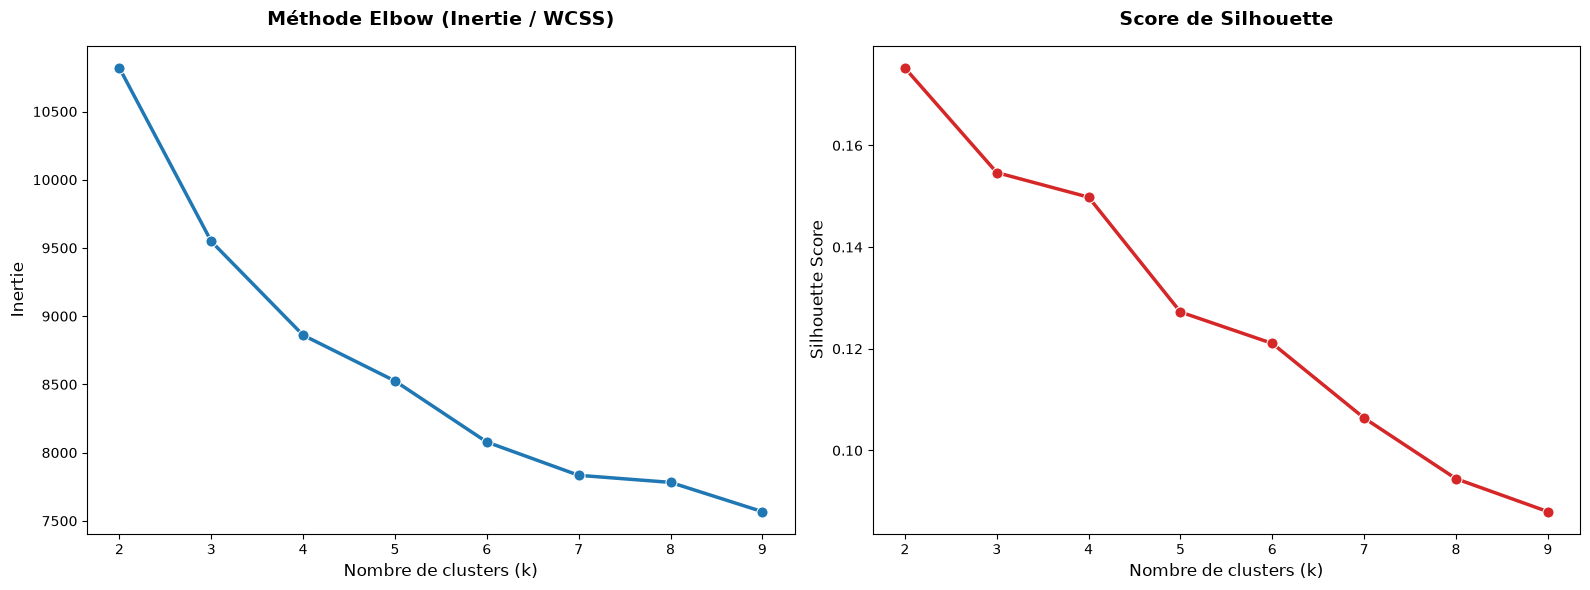

In [33]:
# 3. Création de la figure à 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Méthode Elbow ---
sns.lineplot(
    x=list(k_range), y=inertias, ax=axes[0], 
    marker='o', color='#1f77b4', linewidth=2.5, markersize=8
)
axes[0].set_title('Méthode Elbow (Inertie / WCSS)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertie', fontsize=12)
axes[0].set_xticks(list(k_range))

# --- Graphique 2 : Silhouette Score ---
sns.lineplot(
    x=list(k_range), y=silhouette_scores, ax=axes[1], 
    marker='o', color='#d62728', linewidth=2.5, markersize=8
)
axes[1].set_title('Score de Silhouette', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

In [34]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")

train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

print("Train clusters:", train_clusters[:10])
print("Test clusters:", test_clusters[:10])

score = silhouette_score(X_train, train_clusters)
print("Silhouette score:", score)



Train clusters: [0 1 0 0 0 0 2 0 2 1]
Test clusters: [0 0 2 1 1 1 0 0 0 0]
Silhouette score: 0.15163068851573308


In [35]:
train_clusters_df = pd.DataFrame(train_clusters, columns=['cluster'])

In [36]:
train_clusters_df

,cluster
0,0
1,1
2,0
3,0
4,0
...,...
5611,2
5612,0
5613,2
5614,1


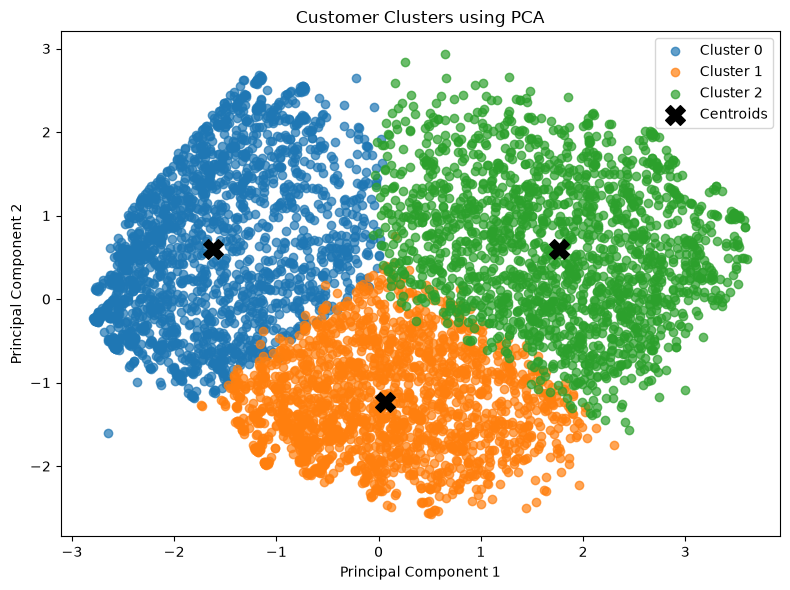

In [40]:
# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
centers_2d = pca.transform(kmeans.cluster_centers_)

# Plot clusters
plt.figure(figsize=(8, 6))
for cluster_id in range(k):
    idx = train_clusters_df['cluster'] == cluster_id
    plt.scatter(
        X_train_2d[idx, 0],
        X_train_2d[idx, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    s=200,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Customer Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()